# Paper LLM scorer

Structured LLM scorer imported from `urbanomy.methods.agent`.


In [1]:
from urbanomy.methods.agent import SingleAgentBaseline, init_llm
from urbanomy.methods.land_value_modeling import Evaluation

llm = init_llm("deepseek/deepseek-v4-flash")
baseline = SingleAgentBaseline(llm=llm, output_schema=Evaluation)

/Users/mvin/Code/paper_1/.venv/lib/python3.11/site-packages/langgraph/cache/base/__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


In [ ]:
import geopandas as gpd
basline_blocks = gpd.read_file('./data/blocks_agg_with_indicators.geojson')
basline_blocks.head()

DataSourceError: /Users/mvin/Code/paper_1/blocks_agg_with_indicators.geojson: No such file or directory

In [ ]:
basline_blocks.iloc[0]

residential                                                  0.690207
business                                                     0.211718
recreation                                                   0.055976
industrial                                                        0.0
transport                                                    0.042093
                                          ...                        
osr                                                         81.852753
share_living                                                 0.126048
share_non_living                                             1.245411
morphotype                                     individual residential
geometry            POLYGON ((30.0936726 59.5520696, 30.09375 59.5...
Name: 0, Length: 112, dtype: object

In [ ]:
from catboost import CatBoostRegressor
model = CatBoostRegressor()
model.load_model('./data/catboost_land_value_no_services.cbm')  # модель на лог-цене
print(len(model.feature_names_))

101


In [ ]:
feature_cols = [
'residential','business','recreation','industrial','transport','special',
'agriculture','land_use','share','footprint_area','build_floor_area',
'living_area','non_living_area','population','site_area','fsi','gsi',
'mxi','l','morphotype','area_accessibility'
]
cat_features = ['land_use', 'morphotype']
numeric_feats = [c for c in feature_cols if c not in cat_features]
basline_blocks["id"] = basline_blocks.index

In [ ]:
basline_blocks['residential'] = basline_blocks['residential'].astype('float64')

In [ ]:
# import geopandas as gpd
# import pandas as pd

# # 1. Переводим в метрическую CRS
# baseline_blocks_metric = basline_blocks.to_crs(basline_blocks.estimate_utm_crs()).copy()

# # 2. Считаем площадь в м2 и гектарах
# baseline_blocks_metric["calc_area_m2"] = baseline_blocks_metric.geometry.area
# baseline_blocks_metric["calc_area_ha"] = baseline_blocks_metric["calc_area_m2"] / 10_000

# # 3. Переводим site_area в гектары
# baseline_blocks_metric["site_area_ha"] = baseline_blocks_metric["site_area"] / 10_000

# # 4. Сравниваем
# baseline_blocks_metric["area_diff_ha"] = (
#     baseline_blocks_metric["calc_area_ha"] - baseline_blocks_metric["site_area_ha"]
# )

# baseline_blocks_metric["area_diff_pct"] = (
#     baseline_blocks_metric["area_diff_ha"] / baseline_blocks_metric["site_area_ha"] * 100
# )

# # 5. Сводка
# print(
#     baseline_blocks_metric[
#         ["site_area_ha", "calc_area_ha", "area_diff_ha", "area_diff_pct"]
#     ].describe()
# )

# # 6. Самые большие расхождения
# comparison_ha = baseline_blocks_metric[
#     ["site_area_ha", "calc_area_ha", "area_diff_ha", "area_diff_pct", "geometry"]
# ].copy()

# comparison_ha["abs_area_diff_pct"] = comparison_ha["area_diff_pct"].abs()
# comparison_ha.sort_values("abs_area_diff_pct", ascending=False).head(10)


In [ ]:
# удаляем старую колонку
basline_blocks = basline_blocks.drop(columns=["site_area"], errors="ignore").copy()

# пересчитываем площадь в метрической CRS
basline_blocks_metric = basline_blocks.to_crs(basline_blocks.estimate_utm_crs()).copy()
basline_blocks["site_area"] = basline_blocks_metric.geometry.area.values


In [ ]:
from urbanomy.methods.land_value_modeling import LandPriceEstimator

estimator = LandPriceEstimator(
    model=model,
    orig_features=numeric_feats+cat_features,
    categorical_features=cat_features,
    blocks=basline_blocks, #or blocks_198
)
blocks_pred = estimator.predict()
blocks_pred.head()


,residential,business,recreation,industrial,transport,special,agriculture,land_use,share,is_living,...,mxi,l,osr,share_living,share_non_living,morphotype,geometry,id,site_area,land_value
0,0.690207,0.211718,0.055976,0.0,0.042093,0.0,0.0,LandUse.RESIDENTIAL,0.690207,6.0,...,0.091908,1.371459,81.852753,0.126048,1.245411,individual residential,"POLYGON ((30.09367 59.55207, 30.09375 59.55215...",0,215420.389645,4.271508e+08
1,0.970519,0.029484,0.000000,0.0,0.000000,0.0,0.0,LandUse.RESIDENTIAL,0.970519,13.0,...,0.712492,5.824002,4.541808,4.149554,1.674447,mid-rise,"POLYGON ((30.09448 59.56164, 30.09448 59.56164...",1,108166.972589,7.165331e+08
2,0.936589,0.010562,0.052849,0.0,0.000000,0.0,0.0,LandUse.RESIDENTIAL,0.936589,15.0,...,0.786029,5.365401,3.107955,4.217362,1.148039,mid-rise,"POLYGON ((30.12546 59.58002, 30.12541 59.57998...",2,77911.495727,6.314014e+08
3,0.121353,0.819171,0.059489,0.0,0.000000,0.0,0.0,LandUse.BUSINESS,0.819171,2.0,...,0.198114,2.288643,5.319595,0.453413,1.835230,low-rise model,"POLYGON ((30.12501 59.56588, 30.12497 59.56582...",3,32058.270586,1.389803e+08
4,0.068737,0.931312,0.000000,0.0,0.000000,0.0,0.0,LandUse.BUSINESS,0.931312,2.0,...,0.095598,2.187029,5.924533,0.209075,1.977953,low-rise model,"POLYGON ((30.1249 59.56574, 30.12497 59.56582,...",4,30779.356283,9.810036e+07


count       333.000000
mean     364557.459112
std      169348.637187
min           0.000000
25%      196315.598988
50%      391430.585333
75%      496662.010120
max      700303.036373
Name: land_value_per_100m2, dtype: float64


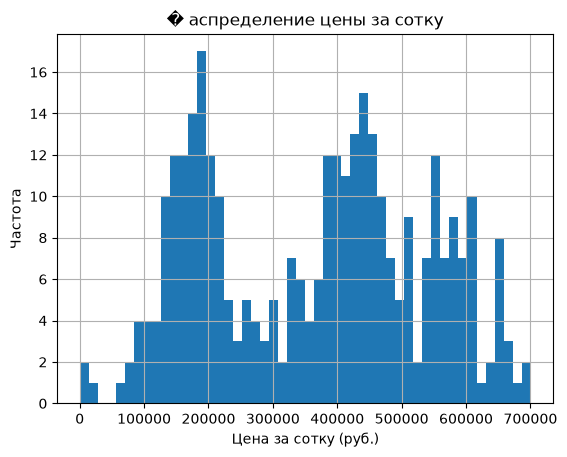

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
# 1) Цена за сотку (100 м²)
blocks_pred["land_value_per_100m2"] = blocks_pred["land_value"] / blocks_pred["site_area"] * 100

# 2) Заменяем inf на NaN
blocks_pred = blocks_pred.replace([np.inf, -np.inf], np.nan)
blocks_pred = blocks_pred.fillna(0)

# 3) Удаляем выбросы: оставляем данные до 99-го перцентиля
p99 = blocks_pred["land_value_per_100m2"].quantile(0.95)
blocks_clean = blocks_pred[blocks_pred["land_value_per_100m2"] <= p99].copy()

print(blocks_clean["land_value_per_100m2"].describe())

# 4) Гистограмма после очистки
plt.figure()
blocks_clean["land_value_per_100m2"].dropna().hist(bins=50)
plt.xlabel("Цена за сотку (руб.)")
plt.ylabel("Частота")
plt.title("� аспределение цены за сотку")
plt.show()



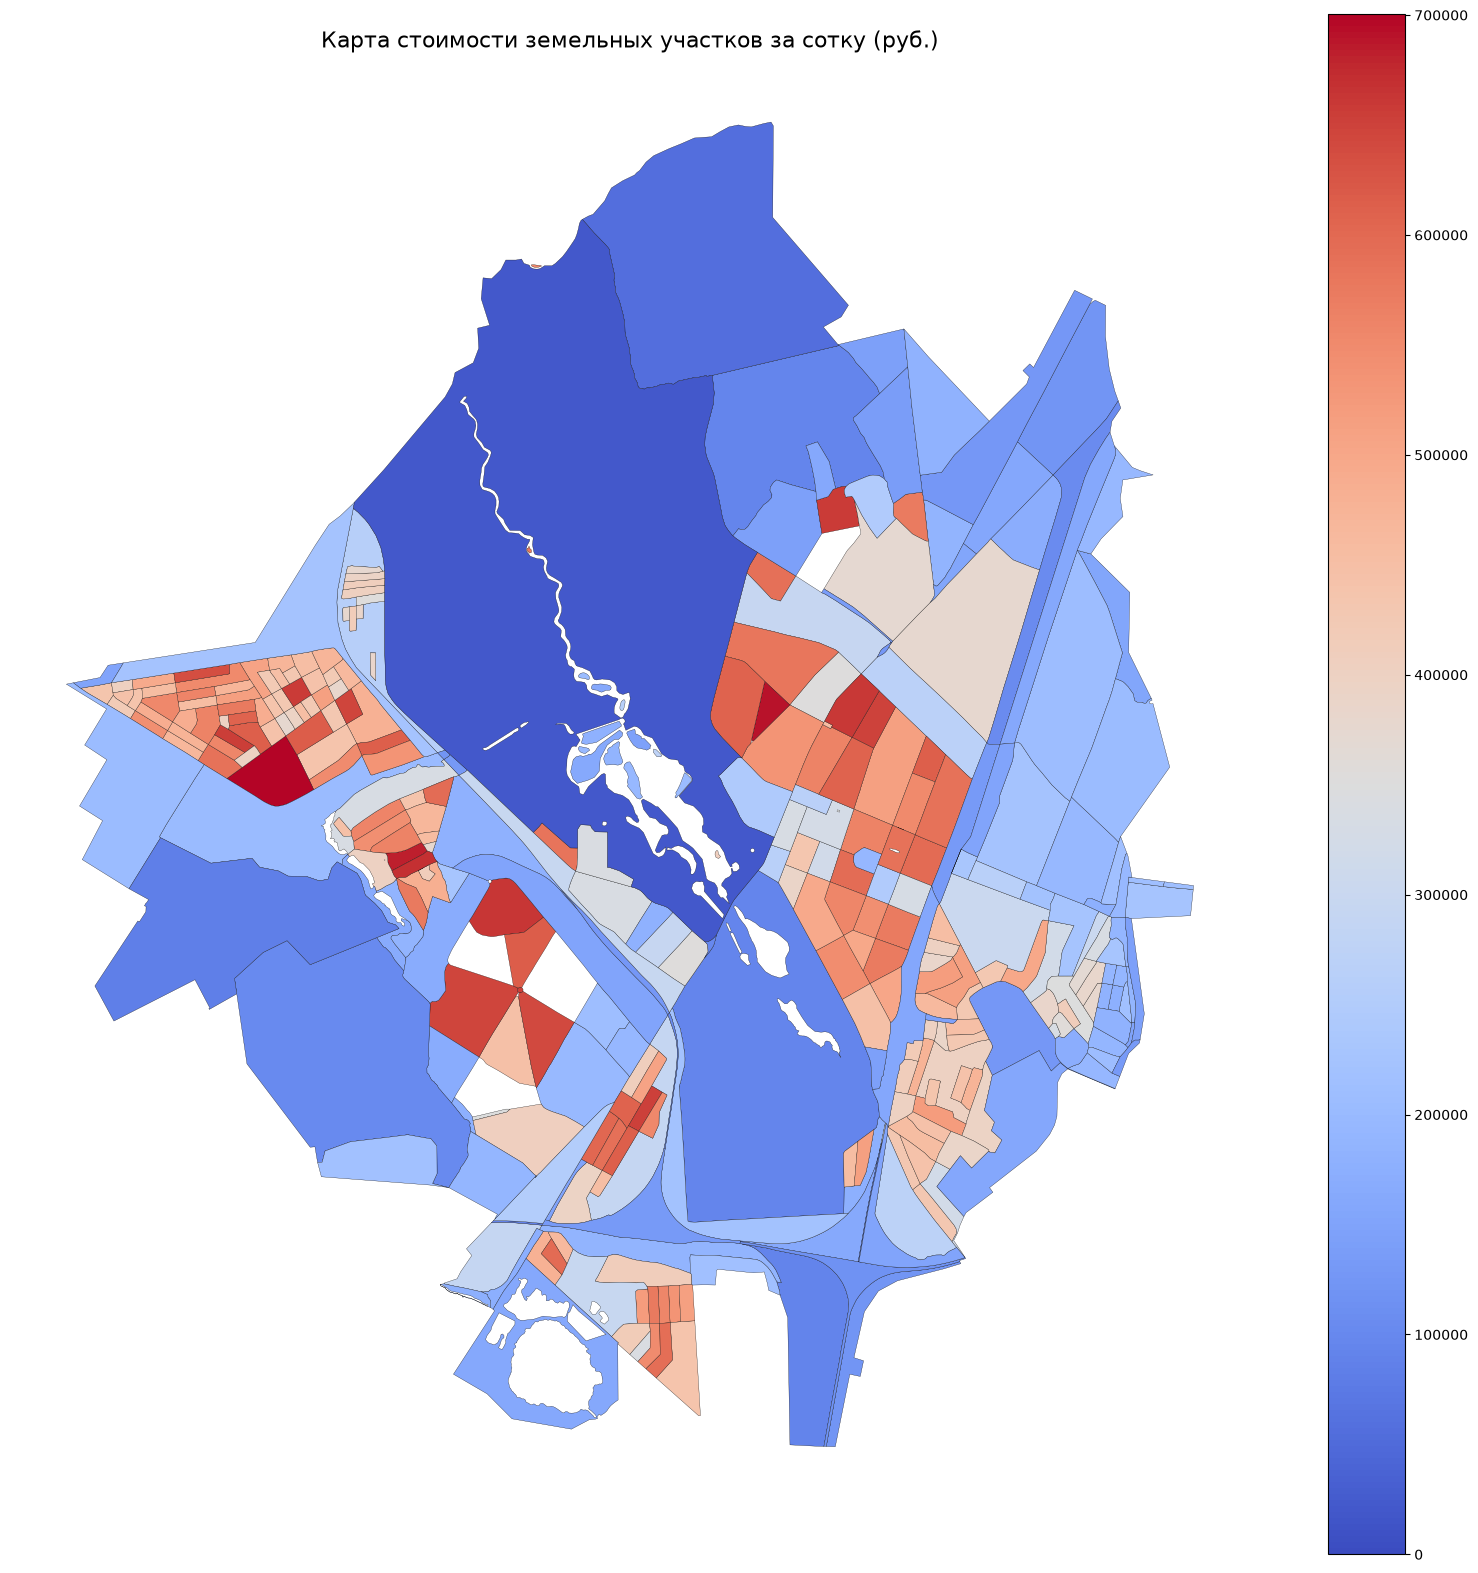

In [ ]:
import matplotlib.pyplot as plt

blocks_clean.plot(
    column='land_value_per_100m2',
    legend=True,
    figsize=(20,20),
    cmap='coolwarm',
    edgecolor='black',   # <-- цвет границы
    linewidth=0.2        # <-- толщина границы
).set_axis_off()
plt.title('Карта стоимости земельных участков за сотку (руб.)', fontsize=16)

plt.show()

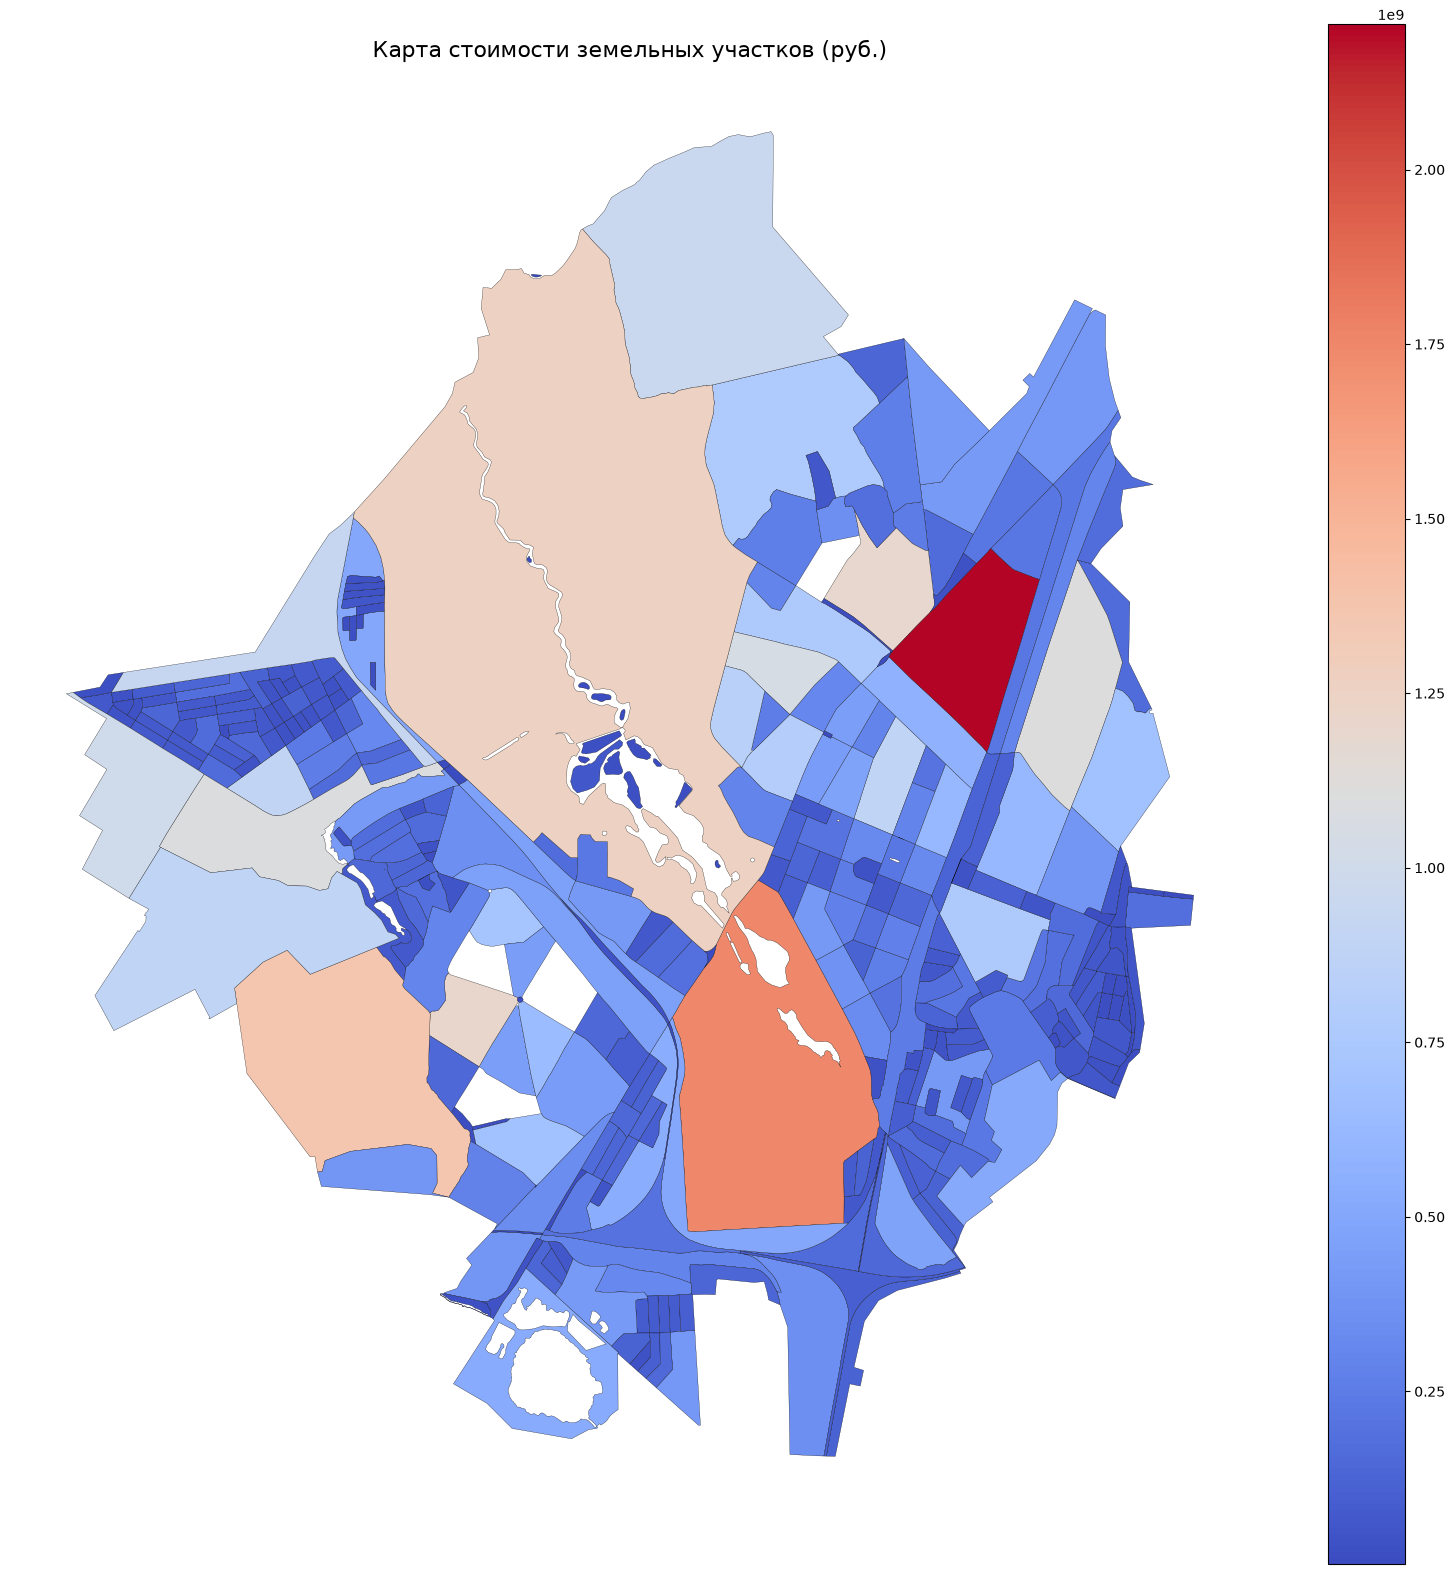

In [ ]:
import matplotlib.pyplot as plt

blocks_clean.plot(
    column='land_value',
    legend=True,
    figsize=(20,20),
    cmap='coolwarm',
    edgecolor='black',   # <-- цвет границы
    linewidth=0.2        # <-- толщина границы
).set_axis_off()
plt.title('Карта стоимости земельных участков (руб.)', fontsize=16)

plt.show()

# Выбор сценария развития

In [ ]:
blocks_clean["id"] = blocks_clean.index

In [ ]:
target_id = 86

/var/folders/p2/g62_fg4547gdlj7_mqyl3nq80000gn/T/ipykernel_8473/4044864446.py:9: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  target_block.centroid.plot(ax=ax, color="red", markersize=30, zorder=3)


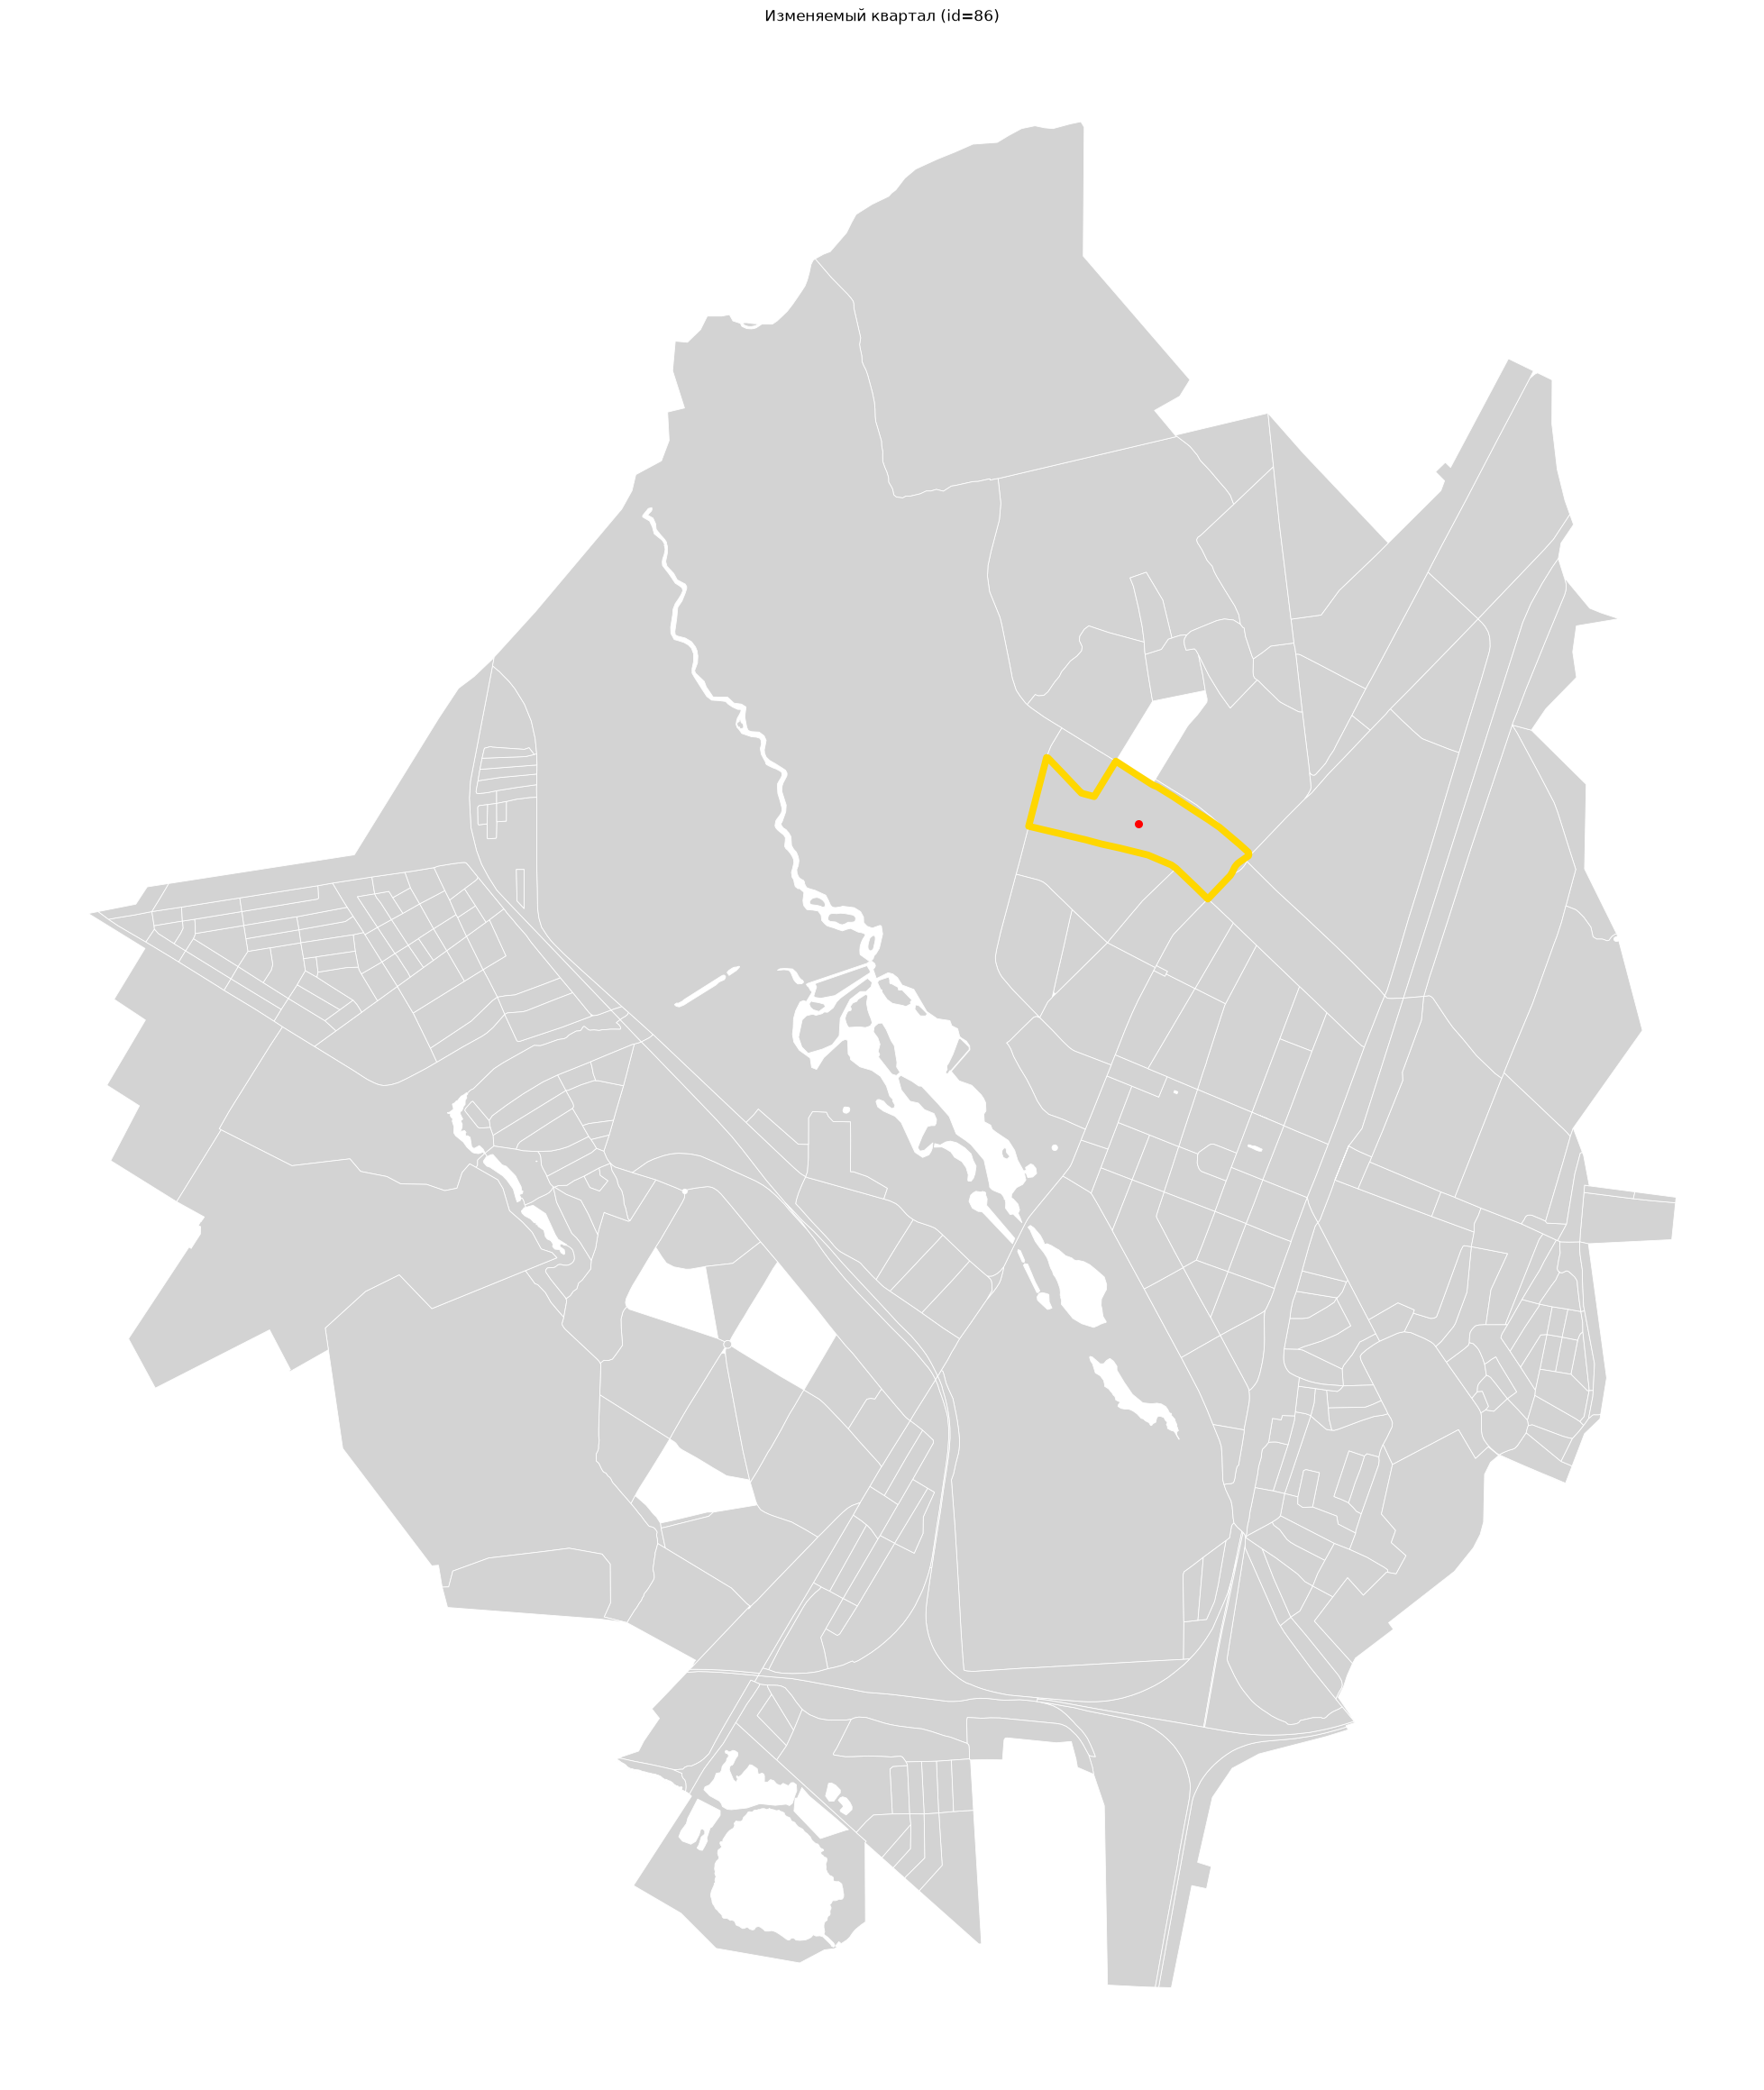

In [ ]:
import matplotlib.pyplot as plt

target_id = 86
target_block = blocks_clean.loc[blocks_clean["id"] == target_id]

fig, ax = plt.subplots(figsize=(25, 35))
blocks_clean.plot(ax=ax, color="lightgrey", edgecolor="white", linewidth=0.6)
target_block.plot(ax=ax, color="none", edgecolor="gold", linewidth=5.5)
target_block.centroid.plot(ax=ax, color="red", markersize=30, zorder=3)

ax.set_title(f"Изменяемый квартал (id={target_id})")
ax.axis("off")
plt.show()


In [ ]:
# blocks_after.to_file('./data/test/gatchina_RESIDENTIAL.geojson', driver='GeoJSON')

# Оптимизация района

## NSGA 2

In [ ]:
prompts = {
    1: """
Evaluate the presented scenario based on the criterion of social inclusiveness and low displacement risk.
Determine whether the scenario preserves the social and functional diversity of the area, access to everyday services, and opportunities for vulnerable user groups.
Assign a score from 0 to 1.
""".strip(),
    2: """
Evaluate the presented scenario based on the criterion of strategic relevance for the long-term development of the city and district.
Consider compactness, functional mix, the balance of housing, jobs, and services, and the area's ability to adapt to future changes.
Assign a score from 0 to 1.
""".strip(),
    3: """
Evaluate the presented scenario based on its ability to create conditions for active urban life.
Consider functional mix, the potential for active ground floors, pedestrian accessibility, public spaces, and diverse everyday use scenarios throughout the day and evening.
Assign a score from 0 to 1.
""".strip(),
    4: """
Evaluate the presented scenario based on the criterion of aligning the interests of various land users and minimizing conflict risk.
Analyze potential conflicts between residents, pedestrians, drivers, business owners, visitors, employees, seniors, and families with children.
Assign a score from 0 to 1.
""".strip(),
    5: """
Evaluate the presented scenario based on the criterion of environmental and infrastructure sustainability.
Consider building density, transport and infrastructure load, resource efficiency, environmental consequences, and the possibility of phased adaptation of the area.
Assign a score from 0 to 1.
""".strip(),
}

In [ ]:
site_area = float(blocks_clean.loc[blocks_clean["id"] == target_id, "site_area"].iloc[0])

constraints = {
    "footprint_area": {"type": "float", "min": 0.0, "max": 0.1 * site_area},
    "l": {"type": "float", "min": 1.0, "max": 10.0},
    "mxi": {"type": "float", "min": 0.1, "max": 1.0},

    "residential": {"type": "float", "min": 0.0, "max": 1.0},
    "business": {"type": "float", "min": 0.0, "max": 1.0},
    "recreation": {"type": "float", "min": 0.0, "max": 1.0},
    "industrial": {"type": "float", "min": 0.0, "max": 1.0},
    "transport": {"type": "float", "min": 0.0, "max": 1.0},
    "special": {"type": "float", "min": 0.0, "max": 1.0},
    "agriculture": {"type": "float", "min": 0.0, "max": 1.0},
}

from urbanomy.methods.land_value_modeling import (
    build_pareto_front_dataframe,
    run_nsga2_with_strategic_alignment,
)
from pathlib import Path
import pandas as pd

notebook_dir = Path("examples") if Path("examples/paper.ipynb").exists() else Path(".")
results_dir = notebook_dir / "nsga_2_llm_prompts"
seed = 41
seed_dir = results_dir / f"seed_{seed}"
seed_dir.mkdir(parents=True, exist_ok=True)

json_rule = '\nReturn only valid JSON, no markdown: {"score": 0.0}'

for prompt_id, prompt in prompts.items():
    prompt_dir = seed_dir / f"prompt_{prompt_id}"
    prompt_dir.mkdir(parents=True, exist_ok=True)

    optimization_log_path = prompt_dir / f"prompt_{prompt_id}_optimization_log.jsonl"
    pareto_front_path = prompt_dir / f"prompt_{prompt_id}_pareto_front.jsonl"

    if optimization_log_path.exists() and pareto_front_path.exists():
        continue

    res, problem = run_nsga2_with_strategic_alignment(
        blocks=blocks_clean,
        model=model,
        estimator_kwargs={
            "orig_features": numeric_feats + cat_features,
            "categorical_features": cat_features,
        },
        constraints=constraints,
        target_id=target_id,
        baseline=baseline,
        prompt=prompt + json_rule,
        pop_size=20,
        n_gen=30,
        seed=seed,
        verbose=True,
        save_history=True,
        log_optimization=True,
        optimization_log_path=optimization_log_path,
    )

    pareto_prompt_df = build_pareto_front_dataframe(res=res, problem=problem)
    pareto_prompt_df.insert(0, "prompt_id", prompt_id)
    pareto_prompt_df.to_json(pareto_front_path, orient="records", lines=True, force_ascii=False)